# Esercizi

## 1. Distribuzioni di probabilità

### Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1. Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

### Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

### Stima il parametro di forma dal campione usando il metodo fit.

### Extra: Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

### Traccia la funzione di distribuzione cumulativa (CDF).

### Calcola la varianza.

In [80]:
# 1000 valori casuali da una gamma di parametro di forma = 1

import scipy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist = sp.stats.gamma(a=1, scale=1)
n = 1000
sample = dist.rvs(size=n)

sample

array([5.40214956e-01, 1.10488229e+00, 2.34527358e-02, 2.00605271e+00,
       2.68254134e-01, 2.07978291e-01, 1.44014365e-01, 8.11597116e-01,
       2.85645813e-01, 3.05666958e+00, 1.59207405e+00, 1.58130288e+00,
       1.72594782e+00, 2.86720253e-01, 2.07468002e-01, 8.31240567e-01,
       1.32973615e+00, 1.09035601e-01, 4.57904008e-01, 2.11461062e-01,
       1.32705970e-01, 1.43873948e+00, 2.14197706e-01, 8.28322310e-02,
       2.01482476e-01, 3.41702999e-01, 1.44712934e+00, 7.99505510e-01,
       3.83062062e+00, 2.91590904e-01, 4.41298315e-01, 1.00165147e+00,
       4.80704339e-01, 7.09935006e-02, 5.04844006e-01, 8.78963397e-01,
       2.17081316e-01, 9.09614766e-01, 1.88895197e-01, 4.10861171e-01,
       1.05482894e+00, 1.21109333e-01, 1.11874501e-02, 4.54219550e-03,
       1.70114419e-01, 3.95484926e-01, 1.45500142e+00, 7.99570424e-01,
       2.77129553e+00, 1.01181976e+00, 1.54109085e+00, 4.91825122e-01,
       7.77178499e-01, 3.27380456e+00, 6.79275434e-01, 1.90816207e+00,
      

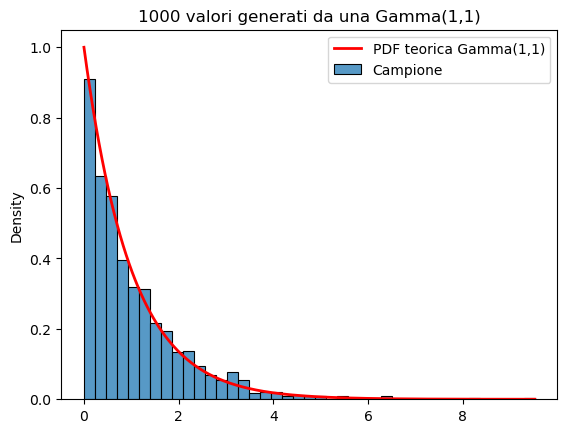

In [81]:
# istogramma campione + pdf teorica

x_vals = np.linspace(0, sample.max(), 300)

sns.histplot(x=sample, stat="density", label="Campione")

plt.plot(x_vals, dist.pdf(x_vals),'r-', lw=2, label="PDF teorica Gamma(1,1)")
plt.title("1000 valori generati da una Gamma(1,1)")
plt.legend()
plt.show()

In [82]:
# stimiamo il parametro forma con fit

a, loc, scale = sp.stats.gamma.fit(sample)
print(f"a = {a}")


a = 1.0278090103202326


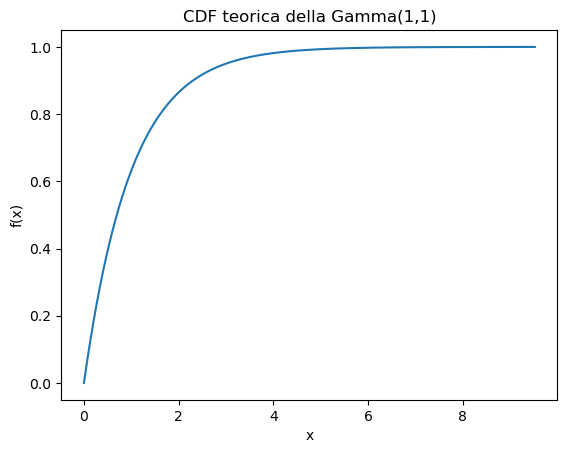

In [83]:
# traccia la CDF

x = np.linspace(0, sample.max(), 1000)

plt.plot(x, dist.cdf(x))
plt.title("CDF teorica della Gamma(1,1)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

In [84]:
# Calcola la varianza

sample.var(ddof=1) #ddof serve per dividere per n-1

np.float64(1.123838710621861)

## 2. Fitta i dati

### Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE

In [85]:
import math

def calc_rmse(y_real, y_pred):
    
    if len(y_real) != len(y_pred):
        raise ValueError("Le liste devono avere stessa lunghezza")
    
    mse = sum((y_real[i] - y_pred[i]) ** 2 for i in range (len(y_real))) / len(y_real)
    
    return math.sqrt(mse)

def calc_mae(y_real, y_pred):
    
    if len(y_real) != len(y_pred):
        raise ValueError("Le liste devono avere stessa lunghezza")
    
    err = [abs(y_real[i] - y_pred[i]) for i in range (len(y_real))]
    
    return sum(err)/len(err)

def sinusoide(x, A, B, C, D):
    return A * np.sin(B * x + C) + D



temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])

x_max = np.arange(1, temp_max.size + 1)
x_min = np.arange(1, temp_min.size + 1)


popt_max, _ = sp.optimize.curve_fit(sinusoide, x_max, temp_max, p0=[10, 2*np.pi/12, -2, 25])
fit_max = sinusoide(x_max, *popt_max)


popt_min, _ = sp.optimize.curve_fit(sinusoide, x_min, temp_min, p0=[25, 2*np.pi/12, -2, -35])
fit_min = sinusoide(x_min, *popt_min)

mae_max  = calc_mae(list(temp_max), list(fit_max))
rmse_max = calc_rmse(list(temp_max), list(fit_max))

mae_min  = calc_mae(list(temp_min), list(fit_min))
rmse_min = calc_rmse(list(temp_min), list(fit_min))

print(f"MAE MAX: {mae_max} RMSE MAX: {rmse_max}\nMAE MIN: {mae_min} RMSE MIN: {rmse_min}")




MAE MAX: 0.7720553289782401 RMSE MAX: 0.847902266486672
MAE MIN: 2.3410100502356044 RMSE MIN: 2.697276717051241


Usiamo la curva sinusoidale perché si adatta bene all'andamento stagionale della temperatura

## 

## 3. Modello di regressione lineare dei seguenti dati

### Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars dove:

### mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

### disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [86]:
# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


In [87]:
#pulizia colonne interessate

df = df.dropna(subset=["mpg", "disp"])
df = df.sort_values(by="disp", ascending=True)
df


,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
19,Toyota Corolla,33.9,4,71.1,65,4.22,1.835,19.90,1,1,4,1
18,Honda Civic,30.4,4,75.7,52,4.93,1.615,18.52,1,1,4,2
17,Fiat 128,32.4,4,78.7,66,4.08,2.200,19.47,1,1,4,1
25,Fiat X1-9,27.3,4,79.0,66,4.08,1.935,18.90,1,1,4,1
27,Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.90,1,1,5,2
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
20,Toyota Corona,21.5,4,120.1,97,3.70,2.465,20.01,1,0,3,1
26,Porsche 914-2,26.0,4,120.3,91,4.43,2.140,16.70,0,1,5,2
31,Volvo 142E,21.4,4,121.0,109,4.11,2.780,18.60,1,1,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2


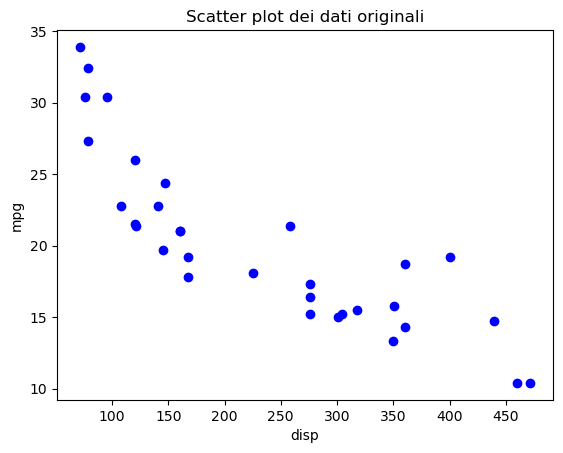

In [88]:

x = df["disp"]
x = np.array(x)

y = df["mpg"]
y = np.array(y)

plt.scatter(x, y, color="blue")
plt.title("Scatter plot dei dati originali")
plt.xlabel("disp")
plt.ylabel("mpg")
plt.show()




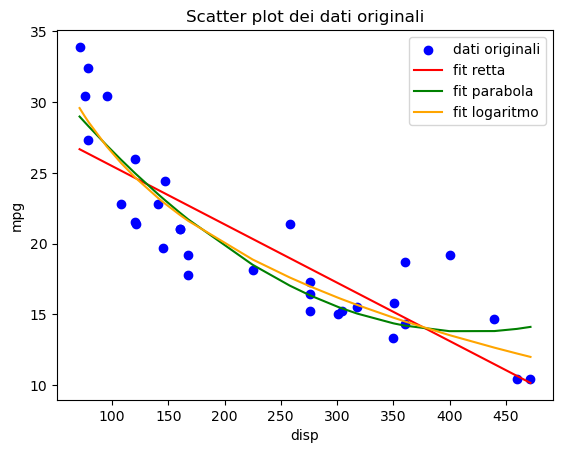

Lineare → MAE: 2.6054734857610686  RMSE: 3.1482072740002796
Parabola → MAE: 2.1738231671473742  RMSE: 2.7006548415264584
Logaritmo → MAE: 2.062921134132247  RMSE: 2.4967286188309816


In [89]:
# FIT COL LOGARITMO
def log_model(x, a, b):
    return a * np.log(x) + b

params, _ = sp.optimize.curve_fit(log_model, x, y)
a, b = params

fit_log = log_model(x, a, b)


# FIT CON UNA PARABOLA
def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

params, _ = sp.optimize.curve_fit(quadratic, x, y)
a, b, c = params

fit_par = quadratic(x, a, b, c)

# FIT CON UNA RETTA
slope, intercept, r_value, p_value, std_err = sp.stats.linregress(x, y)
fit_lin = slope * x + intercept

#FIT POLINOMIALE - Sono equivalenti al fit con la parabola
# coeffs_poly = np.polyfit(x, y, 2) 
# fit_pol_1 = np.polyval(coeffs_poly, x)
# #oppure 
# poly_deg2 = np.poly1d(coeffs_poly)
# fit_pol_2 = poly_deg2(x)

plt.scatter(x, y, label="dati originali", color="blue")
plt.plot(x, fit_lin, label="fit retta", color="red")
plt.plot(x, fit_par, label="fit parabola", color="green")
#plt.plot(x, fit_pol_1, label="fit polinomio_1", color="green")
#plt.plot(x, fit_pol_2, label="fit polinomio 2", color="yellow")
plt.plot(x, fit_log, label="fit logaritmo", color="orange")
plt.legend()
plt.title("Scatter plot dei dati originali")
plt.xlabel("disp")
plt.ylabel("mpg")
plt.show()

models = {
    "Lineare":    fit_lin,
    "Parabola":   fit_par,
    "Logaritmo":  fit_log,
}

for nome, fit in models.items():
    mae  = calc_mae(list(y), list(fit))
    rmse = calc_rmse(list(y), list(fit))
    print(f"{nome} → MAE: {mae}  RMSE: {rmse}")

Osservando i MAE e gli RMSE, il modello più preciso è quello logaritmico (valori più bassi).
Ciò che deduciamo da questo studio è che più aumenta la cilindrata più aumenta il consumo